# Import library

In [183]:
import pandas as pd
import numpy as np
import psycopg2
from sklearn.ensemble import IsolationForest
import joblib
import os

# Database configuration

In [184]:
DB_CONFIG = {
    'host': 'localhost',
    'port': 5432,
    'dbname': 'metrics_db',
    'user': 'mlops',
    'password': 'mlops123'
}

# Loading data

In [191]:
conn = psycopg2.connect(**DB_CONFIG)

df = pd.read_sql(
    "SELECT DISTINCT metric_name FROM metrics",
    con=conn
)

metric_names_list: np.ndarray = df['metric_name'].unique()
metric_names_list

C:\Users\Nguyen Quoc Duong\AppData\Local\Temp\ipykernel_26324\1814025524.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


array(['disk_used_percent', 'net_bytes_recv', 'net_err_out', 'net_err_in',
       'mem_used_percent', 'cpu_usage_active', 'net_bytes_sent'],
      dtype=object)

In [192]:
df = pd.read_sql(
    "SELECT * FROM metrics",
    con=conn
)
df.head(20)

C:\Users\Nguyen Quoc Duong\AppData\Local\Temp\ipykernel_26324\654002547.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(


,id,ts,host_id,metric_name,value
0,186421,2026-07-31 06:49:00+00:00,intern-metrics-server-1,mem_used_percent,1.617978e+01
1,186422,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_recv,1.785760e+07
2,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,2.135908e+07
3,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.000000e+00
4,186425,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_out,0.000000e+00
5,186426,2026-07-31 06:49:00+00:00,intern-metrics-server-1,disk_used_percent,9.038122e+00
6,186427,2026-07-31 06:49:10+00:00,intern-metrics-server-1,cpu_usage_active,1.005025e+00
7,186428,2026-07-31 06:49:30+00:00,intern-metrics-server-1,cpu_usage_active,1.129518e+00
8,186429,2026-07-31 06:49:30+00:00,intern-metrics-server-1,disk_used_percent,9.038162e+00
9,186430,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_recv,1.789242e+07


In [193]:
len(df)

9493

# Visualize data

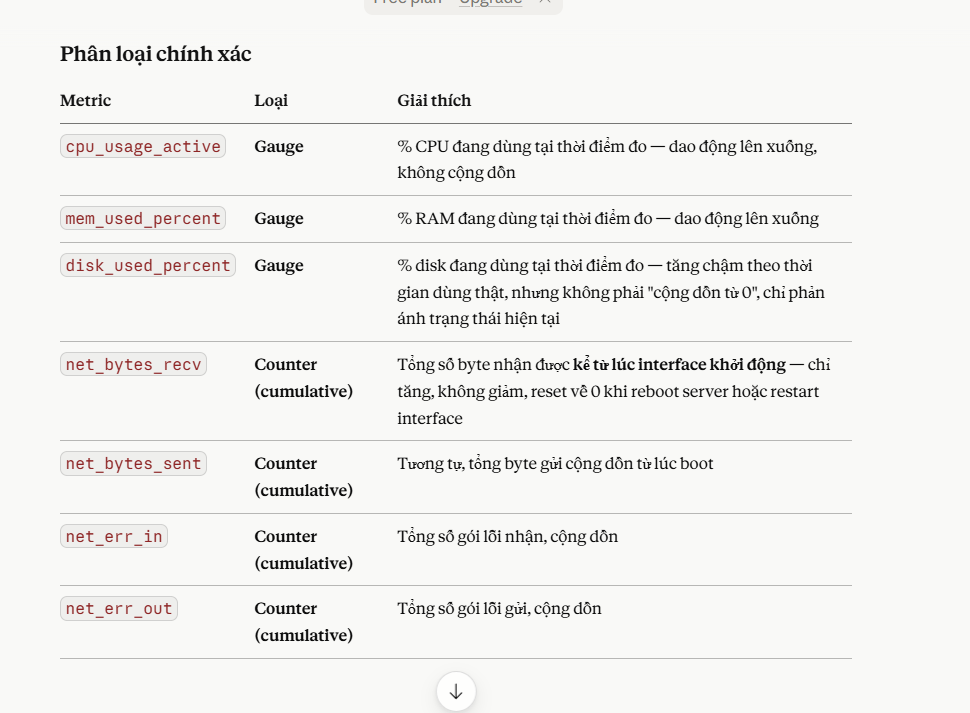

In [194]:
dfs = {metric: group for metric, group in df.groupby('metric_name')}

# tỉ lệ % mà CPU làm việc so với thời gian rảnh
df_cpu: pd.DataFrame = dfs['cpu_usage_active']

# tỉ lệ % lưu trữ trên ổ / mà bị chiếm dụng
df_disk = dfs['disk_used_percent']

# ram còn trống bao nhiêu %
df_mem = dfs['mem_used_percent']

df_network_byte_received = dfs['net_bytes_recv']
df_network_byte_sent = dfs['net_bytes_sent']

# tổng số gói tin card mạng nhận được nhưng gặp lỗi
df_net_err_in = dfs['net_err_in']
# tổng số gói tin mà server gửi đi nhưng bị lỗi
df_net_err_out = dfs['net_err_out']

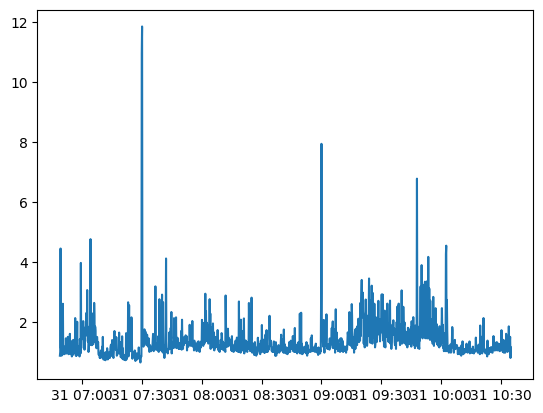

In [195]:
import matplotlib.pyplot as plt

df_cpu = df_cpu.sort_values('ts')

plt.plot(
    df_cpu['ts'],
    df_cpu['value'],
)

plt.show()

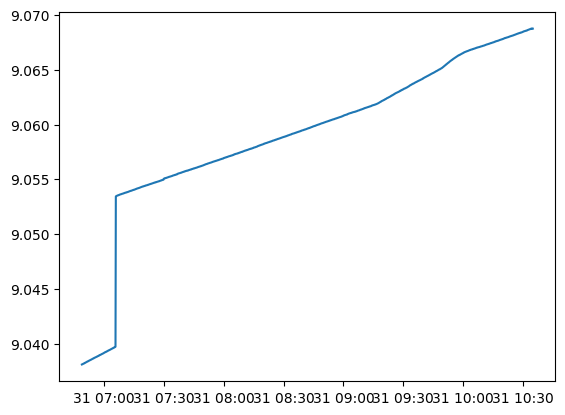

In [196]:
df_disk = df_disk.sort_values('ts')

plt.plot(
    df_disk['ts'],
    df_disk['value'],
)

plt.show()

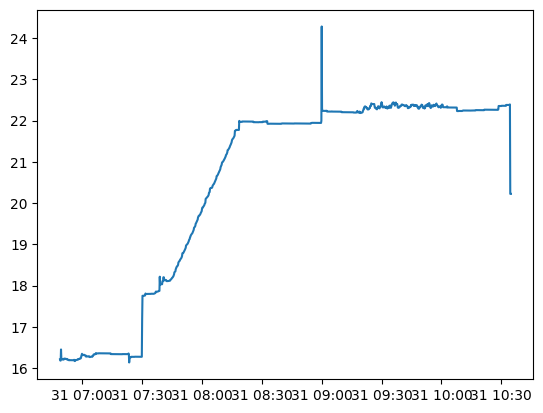

In [197]:
df_mem = df_mem.sort_values('ts')

plt.plot(
    df_mem['ts'],
    df_mem['value'],
)

plt.show()

## Network bytes receieved

Dữ liệu dạng accumulated → tính diff

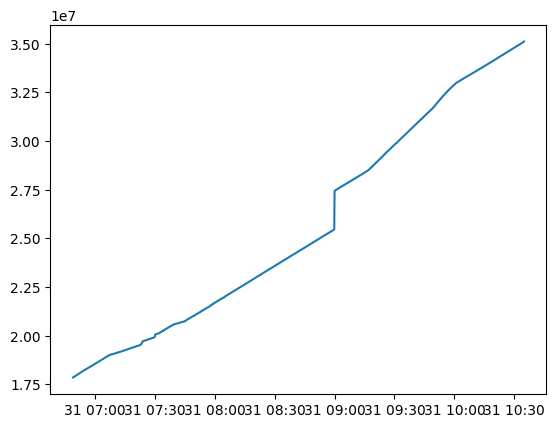

In [198]:
df_network_byte_received = df_network_byte_received.sort_values('ts')

plt.plot(
    df_network_byte_received['ts'],
    df_network_byte_received['value'],
)

plt.show()

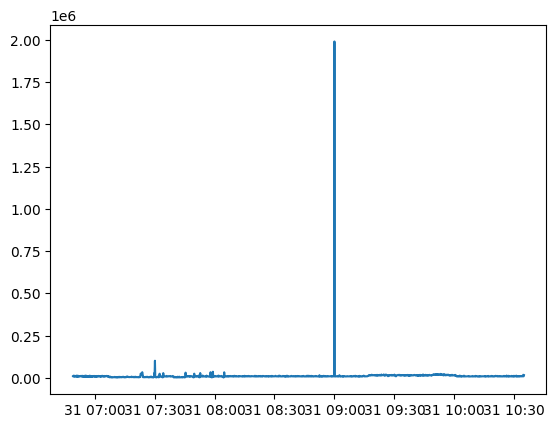

In [199]:
df_network_byte_received['bytes_per_interval'] = df_network_byte_received['value'].diff()

plt.plot(
    df_network_byte_received['ts'], 
    df_network_byte_received['bytes_per_interval']
)

## Network bytes sent

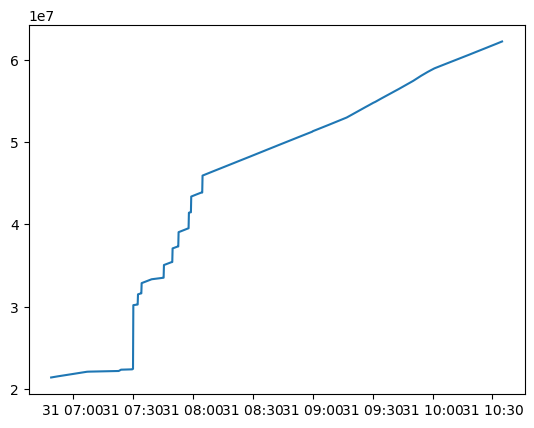

In [200]:
df_network_byte_sent = df_network_byte_sent.sort_values('ts')

plt.plot(
    df_network_byte_sent['ts'],
    df_network_byte_sent['value'],
)

plt.show()

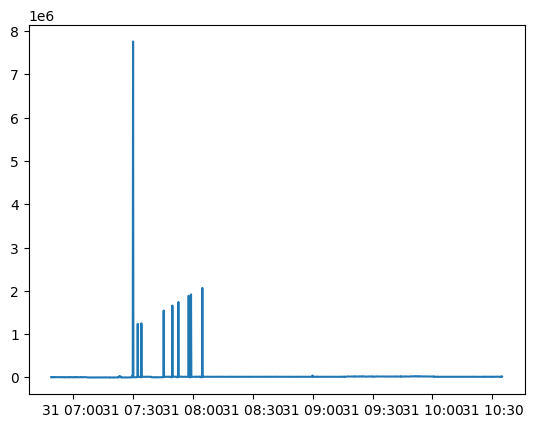

In [201]:
df_network_byte_sent['bytes_per_interval'] = df_network_byte_sent['value'].diff()

plt.plot(
    df_network_byte_sent['ts'], 
    df_network_byte_sent['bytes_per_interval']
)

## Number of error in

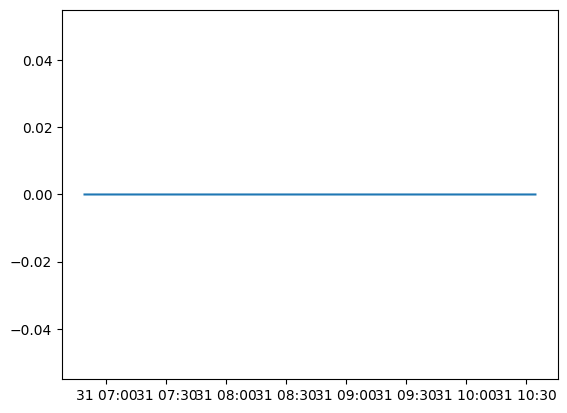

In [202]:
df_net_err_in = df_net_err_in.sort_values('ts')

plt.plot(
    df_net_err_in['ts'],
    df_net_err_in['value'],
)

plt.show()

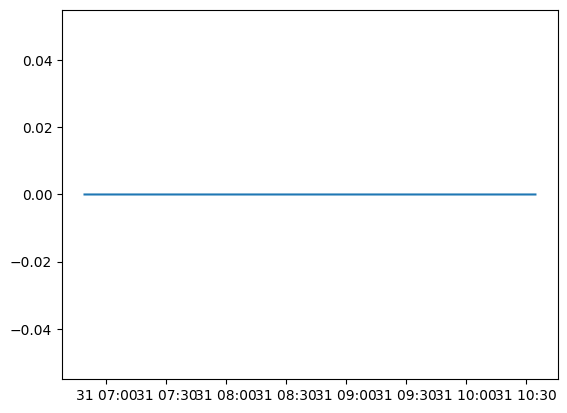

In [203]:
df_net_err_out = df_net_err_out.sort_values('ts')

plt.plot(
    df_net_err_out['ts'],
    df_net_err_out['value'],
)

plt.show()

# Train and evaluation

In [208]:
def build_features(df: pd.DataFrame, window=12) -> pd.DataFrame:
    """
    Sử dụng Rolling mean/std làm feature
    """
    # rolling: (với window=12)
    # giá trị dòng hiện tại được tính dựa trên dòng đó + 11 dòng trước đó
    # với mean: dòng đầu tiên có giá trị bằng chính dòng đó, dòng thứ 2 la fmean của 2 dòng đầu
    # với std: dòng đầu tiên ko tính được vì pandas cần tối thiểu 2 giá trị để tính standard deviation
    df['roll_mean'] = df['value'].rolling(window, min_periods=1).mean()
    df['roll_std']  = df['value'].rolling(window, min_periods=1).std().fillna(0)
    # hàm diff tính toán thay đổi của dòng này với dòng trước đó
    df['diff']      = df['value'].diff().fillna(0)
    return df        

### Isolation Forest: CPU

In [212]:
df_cpu = build_features(df=df_cpu)

In [213]:
df_cpu.head(20)

,id,ts,host_id,metric_name,value,roll_mean,roll_std,diff
1050,187471,2026-07-31 06:49:00+00:00,intern-metrics-server-1,cpu_usage_active,0.879176,0.879176,0.000000,0.000000e+00
6,186427,2026-07-31 06:49:10+00:00,intern-metrics-server-1,cpu_usage_active,1.005025,0.942101,0.088989,1.258490e-01
2136,188557,2026-07-31 06:49:20+00:00,intern-metrics-server-1,cpu_usage_active,4.450591,2.111597,2.026605,3.445566e+00
7,186428,2026-07-31 06:49:30+00:00,intern-metrics-server-1,cpu_usage_active,1.129518,1.866078,1.726037,-3.321073e+00
13,186434,2026-07-31 06:49:40+00:00,intern-metrics-server-1,cpu_usage_active,1.129518,1.718766,1.530656,1.804779e-11
14,186435,2026-07-31 06:49:50+00:00,intern-metrics-server-1,cpu_usage_active,0.878955,1.578797,1.411337,-2.505628e-01
19,186440,2026-07-31 06:50:00+00:00,intern-metrics-server-1,cpu_usage_active,1.155779,1.518366,1.298252,2.768236e-01
2149,188570,2026-07-31 06:50:10+00:00,intern-metrics-server-1,cpu_usage_active,1.054746,1.460414,1.213073,-1.010325e-01
1064,187485,2026-07-31 06:50:20+00:00,intern-metrics-server-1,cpu_usage_active,1.005278,1.409843,1.144823,-4.946865e-02
1066,187487,2026-07-31 06:50:30+00:00,intern-metrics-server-1,cpu_usage_active,2.609787,1.529837,1.144107,1.604509e+00


In [214]:
feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_cpu[feature_cols]
contamination = 0.00001

cpu_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

cpu_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation Forest: disk

In [215]:
df_disk.head(10)

,id,ts,host_id,metric_name,value
5,186426,2026-07-31 06:49:00+00:00,intern-metrics-server-1,disk_used_percent,9.038122
1051,187472,2026-07-31 06:49:10+00:00,intern-metrics-server-1,disk_used_percent,9.038135
2135,188556,2026-07-31 06:49:20+00:00,intern-metrics-server-1,disk_used_percent,9.038155
8,186429,2026-07-31 06:49:30+00:00,intern-metrics-server-1,disk_used_percent,9.038162
2138,188559,2026-07-31 06:49:40+00:00,intern-metrics-server-1,disk_used_percent,9.038182
1059,187480,2026-07-31 06:49:50+00:00,intern-metrics-server-1,disk_used_percent,9.038202
2144,188565,2026-07-31 06:50:00+00:00,intern-metrics-server-1,disk_used_percent,9.038209
20,186441,2026-07-31 06:50:10+00:00,intern-metrics-server-1,disk_used_percent,9.038229
2152,188573,2026-07-31 06:50:20+00:00,intern-metrics-server-1,disk_used_percent,9.038249
1065,187486,2026-07-31 06:50:30+00:00,intern-metrics-server-1,disk_used_percent,9.038249


In [216]:
df_disk = build_features(df=df_disk)

feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_disk[feature_cols]
contamination = 0.00001

disk_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

disk_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation forest: memory

In [217]:
df_mem.head(10)

,id,ts,host_id,metric_name,value
1049,187470,2026-07-31 06:48:50+00:00,intern-metrics-server-1,mem_used_percent,16.208423
0,186421,2026-07-31 06:49:00+00:00,intern-metrics-server-1,mem_used_percent,16.179776
1052,187473,2026-07-31 06:49:10+00:00,intern-metrics-server-1,mem_used_percent,16.179580
2134,188555,2026-07-31 06:49:20+00:00,intern-metrics-server-1,mem_used_percent,16.449067
2137,188558,2026-07-31 06:49:30+00:00,intern-metrics-server-1,mem_used_percent,16.217825
1057,187478,2026-07-31 06:49:40+00:00,intern-metrics-server-1,mem_used_percent,16.217677
1058,187479,2026-07-31 06:49:50+00:00,intern-metrics-server-1,mem_used_percent,16.217529
2143,188564,2026-07-31 06:50:00+00:00,intern-metrics-server-1,mem_used_percent,16.217431
2150,188571,2026-07-31 06:50:10+00:00,intern-metrics-server-1,mem_used_percent,16.204387
2151,188572,2026-07-31 06:50:20+00:00,intern-metrics-server-1,mem_used_percent,16.204190


In [218]:
df_mem = build_features(df=df_mem)

feature_cols = ['value', 'roll_mean', 'roll_std', 'diff']
X = df_mem[feature_cols]
contamination = 0.00001

mem_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=315
)

mem_model.fit(X)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,315
,verbose,0
,warm_start,False


### Isolation Forest: network

In [219]:
df_network_byte_sent.head(5)

,id,ts,host_id,metric_name,value,bytes_per_interval
2,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN
2131,188552,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0
1054,187475,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0
10,186431,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0
2140,188561,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0


In [220]:
df_network_byte_received.head(5)

,id,ts,host_id,metric_name,value,bytes_per_interval
1,186422,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
2130,188551,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
1053,187474,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
9,186430,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
2139,188560,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [221]:
df_net_err_out.head(5)

,id,ts,host_id,metric_name,value
4,186425,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_out,0.0
2133,188554,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_out,0.0
1056,187477,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_out,0.0
12,186433,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_out,0.0
2142,188563,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_out,0.0


In [222]:
df_net_err_in.head(5)

,id,ts,host_id,metric_name,value
3,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0
2132,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0
1055,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0
11,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0
2141,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0


In [224]:
df_net_err_in.describe(), df_net_err_out.describe(), df_network_byte_received.describe(), df_network_byte_sent.describe()

(                  id   value
 count    1356.000000  1356.0
 mean   191159.258850     0.0
 std      2751.404491     0.0
 min    186424.000000     0.0
 25%    188752.500000     0.0
 50%    191168.000000     0.0
 75%    193540.750000     0.0
 max    195911.000000     0.0,
                   id   value
 count    1356.000000  1356.0
 mean   191160.258850     0.0
 std      2751.404491     0.0
 min    186425.000000     0.0
 25%    188753.500000     0.0
 50%    191169.000000     0.0
 75%    193541.750000     0.0
 max    195912.000000     0.0,
                   id         value  bytes_per_interval
 count    1356.000000  1.356000e+03        1.355000e+03
 mean   191157.258850  2.567009e+07        1.273569e+04
 std      2751.404491  5.391647e+06        5.394789e+04
 min    186422.000000  1.785760e+07        3.310000e+03
 25%    188750.500000  2.077782e+07        9.404500e+03
 50%    191166.000000  2.433383e+07        1.030200e+04
 75%    193538.750000  3.062448e+07        1.264500e+04
 max    19

In [225]:
df_net_join_1 = pd.merge(df_net_err_in, df_net_err_out, on='ts', how='inner', suffixes=('_err_in', '_err_out'))
df_net_join_1.head(5)

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0


In [226]:
df_net_join_2 = pd.merge(df_network_byte_sent, df_network_byte_received, on='ts', how='inner', suffixes=('_byte_sent', '_byte_received'))
df_net_join_2.head(5)

,id_byte_sent,ts,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186423,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
1,188552,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187475,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186431,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188561,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [227]:
df_net_join = pd.merge(df_net_join_1, df_net_join_2, on='ts', how='inner')
df_net_join.head()

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out,id_byte_sent,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0,186423,intern-metrics-server-1,net_bytes_sent,21359083.0,NaN,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,NaN
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0,188552,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0,187475,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0,186431,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0,188561,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0


In [228]:
features = [
    'value_err_in',
    'value_err_out',
    'bytes_per_interval_byte_sent',
    'bytes_per_interval_byte_received',
]

In [231]:
df_net_join.fillna(0)

,id_err_in,ts,host_id_err_in,metric_name_err_in,value_err_in,id_err_out,host_id_err_out,metric_name_err_out,value_err_out,id_byte_sent,host_id_byte_sent,metric_name_byte_sent,value_byte_sent,bytes_per_interval_byte_sent,id_byte_received,host_id_byte_received,metric_name_byte_received,value_byte_received,bytes_per_interval_byte_received
0,186424,2026-07-31 06:49:00+00:00,intern-metrics-server-1,net_err_in,0.0,186425,intern-metrics-server-1,net_err_out,0.0,186423,intern-metrics-server-1,net_bytes_sent,21359083.0,0.0,186422,intern-metrics-server-1,net_bytes_recv,17857605.0,0.0
1,188553,2026-07-31 06:49:10+00:00,intern-metrics-server-1,net_err_in,0.0,188554,intern-metrics-server-1,net_err_out,0.0,188552,intern-metrics-server-1,net_bytes_sent,21366695.0,7612.0,188551,intern-metrics-server-1,net_bytes_recv,17868879.0,11274.0
2,187476,2026-07-31 06:49:20+00:00,intern-metrics-server-1,net_err_in,0.0,187477,intern-metrics-server-1,net_err_out,0.0,187475,intern-metrics-server-1,net_bytes_sent,21378687.0,11992.0,187474,intern-metrics-server-1,net_bytes_recv,17882014.0,13135.0
3,186432,2026-07-31 06:49:30+00:00,intern-metrics-server-1,net_err_in,0.0,186433,intern-metrics-server-1,net_err_out,0.0,186431,intern-metrics-server-1,net_bytes_sent,21384935.0,6248.0,186430,intern-metrics-server-1,net_bytes_recv,17892422.0,10408.0
4,188562,2026-07-31 06:49:40+00:00,intern-metrics-server-1,net_err_in,0.0,188563,intern-metrics-server-1,net_err_out,0.0,188561,intern-metrics-server-1,net_bytes_sent,21393599.0,8664.0,188560,intern-metrics-server-1,net_bytes_recv,17906745.0,14323.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,195884,2026-07-31 10:34:10+00:00,intern-metrics-server-1,net_err_in,0.0,195885,intern-metrics-server-1,net_err_out,0.0,195883,intern-metrics-server-1,net_bytes_sent,62221618.0,16059.0,195882,intern-metrics-server-1,net_bytes_recv,35056503.0,10174.0
1352,195890,2026-07-31 10:34:20+00:00,intern-metrics-server-1,net_err_in,0.0,195891,intern-metrics-server-1,net_err_out,0.0,195889,intern-metrics-server-1,net_bytes_sent,62238742.0,17124.0,195888,intern-metrics-server-1,net_bytes_recv,35068602.0,12099.0
1353,195895,2026-07-31 10:34:30+00:00,intern-metrics-server-1,net_err_in,0.0,195896,intern-metrics-server-1,net_err_out,0.0,195894,intern-metrics-server-1,net_bytes_sent,62261590.0,22848.0,195893,intern-metrics-server-1,net_bytes_recv,35087973.0,19371.0
1354,195902,2026-07-31 10:34:40+00:00,intern-metrics-server-1,net_err_in,0.0,195903,intern-metrics-server-1,net_err_out,0.0,195901,intern-metrics-server-1,net_bytes_sent,62272706.0,11116.0,195900,intern-metrics-server-1,net_bytes_recv,35098017.0,10044.0


In [232]:
feature: str

for feature in features:
    feature_name = 'roll_mean_' + feature
    # print(feature_name)
    df_net_join[feature_name] = df_net_join[feature].rolling(window=12, min_periods=1).mean()

In [233]:
df_net_join.columns

Index(['id_err_in', 'ts', 'host_id_err_in', 'metric_name_err_in',
       'value_err_in', 'id_err_out', 'host_id_err_out', 'metric_name_err_out',
       'value_err_out', 'id_byte_sent', 'host_id_byte_sent',
       'metric_name_byte_sent', 'value_byte_sent',
       'bytes_per_interval_byte_sent', 'id_byte_received',
       'host_id_byte_received', 'metric_name_byte_received',
       'value_byte_received', 'bytes_per_interval_byte_received',
       'roll_mean_value_err_in', 'roll_mean_value_err_out',
       'roll_mean_bytes_per_interval_byte_sent',
       'roll_mean_bytes_per_interval_byte_received'],
      dtype='object')

In [234]:
train_features = [
    'value_err_in',
    'value_err_out',
    'bytes_per_interval_byte_sent',
    'bytes_per_interval_byte_received',
    'roll_mean_value_err_in',
    'roll_mean_value_err_out',
    'roll_mean_bytes_per_interval_byte_sent',
    'roll_mean_bytes_per_interval_byte_received',
]

In [249]:
from sklearn.preprocessing import StandardScaler

df_net_train = df_net_join[train_features]

df_net_train = df_net_train.fillna(0)

df_net_train.head(10)

,value_err_in,value_err_out,bytes_per_interval_byte_sent,bytes_per_interval_byte_received,roll_mean_value_err_in,roll_mean_value_err_out,roll_mean_bytes_per_interval_byte_sent,roll_mean_bytes_per_interval_byte_received
0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,0.0,0.0,7612.0,11274.0,0.0,0.0,7612.000000,11274.000000
2,0.0,0.0,11992.0,13135.0,0.0,0.0,9802.000000,12204.500000
3,0.0,0.0,6248.0,10408.0,0.0,0.0,8617.333333,11605.666667
4,0.0,0.0,8664.0,14323.0,0.0,0.0,8629.000000,12285.000000
5,0.0,0.0,4238.0,8457.0,0.0,0.0,7750.800000,11519.400000
6,0.0,0.0,7492.0,11143.0,0.0,0.0,7707.666667,11456.666667
7,0.0,0.0,5530.0,9965.0,0.0,0.0,7396.571429,11243.571429
8,0.0,0.0,7034.0,11382.0,0.0,0.0,7351.250000,11260.875000
9,0.0,0.0,7656.0,11131.0,0.0,0.0,7385.111111,11246.444444


In [252]:
df_net_train.shape

(1356, 8)

In [ ]:
scaler = StandardScaler()

df_net_train = scaler.fit_transform(df_net_train)

df_net_train.shape

(1356, 8)

In [254]:
net_model = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=33,
)

net_model.fit(df_net_train)

,n_estimators,200
,max_samples,'auto'
,contamination,1e-05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,33
,verbose,0
,warm_start,False


# Saving models

In [255]:
joblib.dump(net_model, 'models/net_model.pkl')
joblib.dump(cpu_model, 'models/cpu_model.pkl')
joblib.dump(mem_model, 'models/mem_model.pkl')
joblib.dump(disk_model, 'models/disk_model.pkl')

['models/disk_model.pkl']